正在计算最终参数...


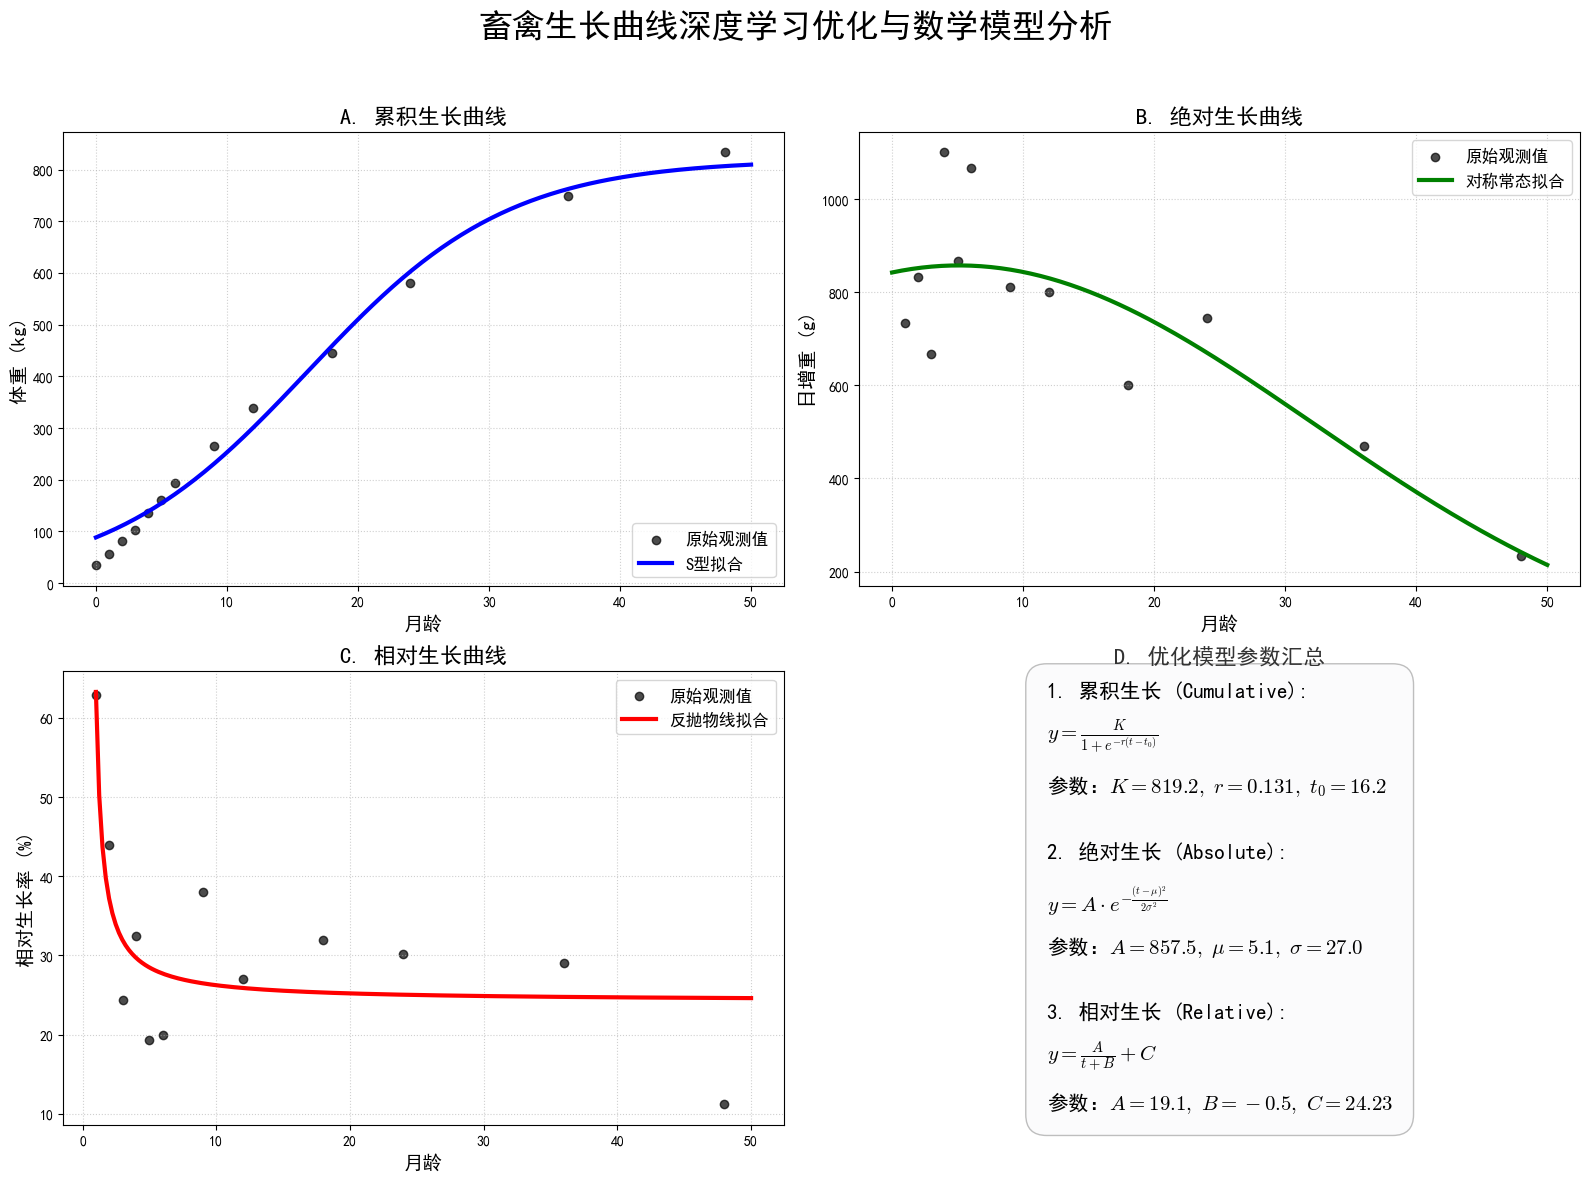

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ================= 0. 全局设置 =================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示
plt.rcParams['mathtext.fontset'] = 'cm'       # 数学公式字体 (Computer Modern)

# ================= 1. 数据录入 (不变) =================
months = torch.tensor([0, 1, 2, 3, 4, 5, 6, 9, 12, 18, 24, 36, 48], dtype=torch.float32).view(-1, 1)
w_cum = torch.tensor([35, 57, 82, 102, 135, 161, 193, 266, 338, 446, 580, 749, 833], dtype=torch.float32).view(-1, 1)
months_sub = months[1:]
w_abs = torch.tensor([733, 833, 667, 1100, 867, 1067, 811, 800, 600, 745, 470, 233], dtype=torch.float32).view(-1, 1)
w_rel = torch.tensor([62.9, 43.9, 24.4, 32.4, 19.3, 19.9, 38.0, 27.0, 32.0, 30.2, 29.1, 11.2], dtype=torch.float32).view(-1, 1)

# ================= 2. 定义模型 (不变) =================
class CumulativeModel(nn.Module):
    def __init__(self): super().__init__(); self.K = nn.Parameter(torch.tensor([900.0])); self.r = nn.Parameter(torch.tensor([0.1])); self.t0 = nn.Parameter(torch.tensor([15.0]))
    def forward(self, t): return self.K / (1 + torch.exp(-self.r * (t - self.t0)))

class AbsoluteModel(nn.Module):
    def __init__(self): super().__init__(); self.A = nn.Parameter(torch.tensor([1000.0])); self.mu = nn.Parameter(torch.tensor([10.0])); self.sigma = nn.Parameter(torch.tensor([10.0]))
    def forward(self, t): return self.A * torch.exp(-((t - self.mu)**2) / (2 * self.sigma**2))

class RelativeModel(nn.Module):
    def __init__(self): super().__init__(); self.A = nn.Parameter(torch.tensor([100.0])); self.B = nn.Parameter(torch.tensor([5.0])); self.C = nn.Parameter(torch.tensor([5.0]))
    def forward(self, t): return self.A / (t + self.B) + self.C

# ================= 3. 训练 (不变) =================
def train_and_extract(model, x, y):
    optimizer = optim.Adam(model.parameters(), lr=0.1)
    loss_fn = nn.MSELoss()
    for _ in range(3000): optimizer.zero_grad(); loss = loss_fn(model(x), y); loss.backward(); optimizer.step()
    return model

print("正在计算最终参数...")
m1 = train_and_extract(CumulativeModel(), months, w_cum)
m2 = train_and_extract(AbsoluteModel(), months_sub, w_abs)
m3 = train_and_extract(RelativeModel(), months_sub, w_rel)

K_val, r_val, t0_val = m1.K.item(), m1.r.item(), m1.t0.item()
A_val, mu_val, sigma_val = m2.A.item(), m2.mu.item(), m2.sigma.item()
A_rel, B_rel, C_rel = m3.A.item(), m3.B.item(), m3.C.item()

# ================= 4. 绘图 (修复重叠与居中) =================
t_smooth = torch.linspace(0, 50, 200).view(-1, 1)
t_smooth_sub = torch.linspace(1, 50, 200).view(-1, 1)

with torch.no_grad():
    y1 = m1(t_smooth).numpy()
    y2 = m2(t_smooth).numpy()
    y3 = m3(t_smooth_sub).numpy()

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
# 将标题稍微上移，或者依赖下面的 rect 参数来预留空间
fig.suptitle('畜禽生长曲线深度学习优化与数学模型分析', fontsize=24, fontweight='bold')

# 图1
axs[0, 0].scatter(months, w_cum, c='black', alpha=0.7, label='原始观测值')
axs[0, 0].plot(t_smooth, y1, c='blue', lw=3, label='S型拟合')
axs[0, 0].set_title('A. 累积生长曲线', fontsize=16, fontweight='bold')
axs[0, 0].set_ylabel('体重 (kg)', fontsize=14); axs[0, 0].set_xlabel('月龄', fontsize=14); axs[0, 0].grid(True, ls=':', alpha=0.6); axs[0, 0].legend(fontsize=12, loc='lower right')

# 图2
axs[0, 1].scatter(months_sub, w_abs, c='black', alpha=0.7, label='原始观测值')
axs[0, 1].plot(t_smooth, y2, c='green', lw=3, label='对称常态拟合')
axs[0, 1].set_title('B. 绝对生长曲线', fontsize=16, fontweight='bold')
axs[0, 1].set_ylabel('日增重 (g)', fontsize=14); axs[0, 1].set_xlabel('月龄', fontsize=14); axs[0, 1].grid(True, ls=':', alpha=0.6); axs[0, 1].legend(fontsize=12)

# 图3
axs[1, 0].scatter(months_sub, w_rel, c='black', alpha=0.7, label='原始观测值')
axs[1, 0].plot(t_smooth_sub, y3, c='red', lw=3, label='反抛物线拟合')
axs[1, 0].set_title('C. 相对生长曲线', fontsize=16, fontweight='bold')
axs[1, 0].set_ylabel('相对生长率 (%)', fontsize=14); axs[1, 0].set_xlabel('月龄', fontsize=14); axs[1, 0].grid(True, ls=':', alpha=0.6); axs[1, 0].legend(fontsize=12)

# --- 图4：修复部分 ---
ax_text = axs[1, 1]
ax_text.axis('off')
ax_text.set_title('D. 优化模型参数汇总', fontsize=16, fontweight='bold', color='#333333')

combined_text = (
    "1. 累积生长曲线拟合公式:\n" +
    r"$y = \frac{K}{1 + e^{-r(t - t_0)}}$" + "\n" +
    rf"参数：$K={K_val:.1f}, \ r={r_val:.3f}, \ t_0={t0_val:.1f}$" + "\n\n"
    
    "2. 绝对生长曲线拟合公式:\n" +
    r"$y = A \cdot e^{-\frac{(t - \mu)^2}{2\sigma^2}}$" + "\n" +
    rf"参数：$A={A_val:.1f}, \ \mu={mu_val:.1f}, \ \sigma={sigma_val:.1f}$" + "\n\n"
    
    "3. 相对生长曲线拟合公式:\n" +
    r"$y = \frac{A}{t + B} + C$" + "\n" +
    rf"参数：$A={A_rel:.1f}, \ B={B_rel:.1f}, \ C={C_rel:.2f}$"
)

# 【关键修改】：
# 1. (0.5, 0.5) 放到正中心
# 2. ha='center', va='center' 确保整个块居中
# 3. multialignment='left' 确保文本块内部是整齐的（如果设为center，每一行长短不一会很难看）
ax_text.text(0.5, 0.5, combined_text, 
             fontsize=15, 
             horizontalalignment='center',
             verticalalignment='center',
             multialignment='left', 
             bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='gray', alpha=0.5),
             linespacing=1.8)

# 【关键修改】：rect=[0, 0, 1, 0.95]
# 意思是：布局只使用从 0 到 0.95 的高度，上面留 5% 给 suptitle，彻底解决重叠
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

正在训练 MLP 模型 (这可能需要几秒钟)...
训练完成！


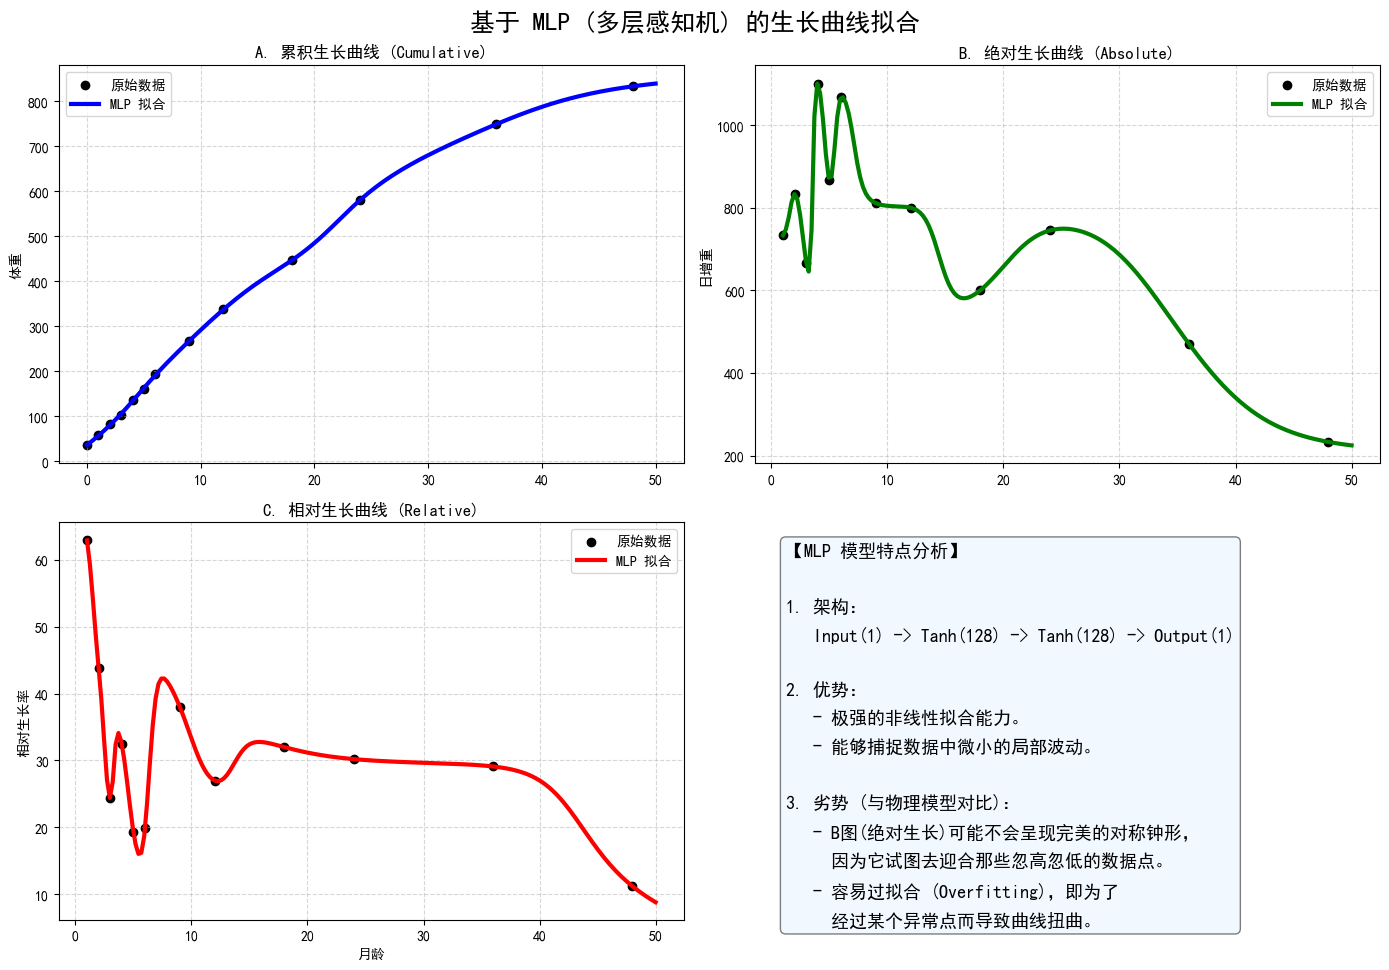

In [4]:
# ================= 0. 设置中文字体与画布 =================
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# ================= 1. 数据准备 =================
# 原始数据
months = torch.tensor([0, 1, 2, 3, 4, 5, 6, 9, 12, 18, 24, 36, 48], dtype=torch.float32).view(-1, 1)
w_cum = torch.tensor([35, 57, 82, 102, 135, 161, 193, 266, 338, 446, 580, 749, 833], dtype=torch.float32).view(-1, 1)

months_sub = months[1:]
w_abs = torch.tensor([733, 833, 667, 1100, 867, 1067, 811, 800, 600, 745, 470, 233], dtype=torch.float32).view(-1, 1)
w_rel = torch.tensor([62.9, 43.9, 24.4, 32.4, 19.3, 19.9, 38.0, 27.0, 32.0, 30.2, 29.1, 11.2], dtype=torch.float32).view(-1, 1)

# === 关键步骤：数据标准化 (Normalization) ===
# 神经网络对数值范围非常敏感，必须把数据压缩到 0~1 或 -1~1 之间
def normalize(tensor):
    mean = tensor.mean()
    std = tensor.std()
    return (tensor - mean) / std, mean, std

def denormalize(tensor, mean, std):
    return tensor * std + mean

# 对三组数据分别标准化
x_norm, x_mean, x_std = normalize(months)
x_sub_norm, x_sub_mean, x_sub_std = normalize(months_sub)

y_cum_norm, y_cum_mean, y_cum_std = normalize(w_cum)
y_abs_norm, y_abs_mean, y_abs_std = normalize(w_abs)
y_rel_norm, y_rel_mean, y_rel_std = normalize(w_rel)

# ================= 2. 定义 MLP 网络架构 =================
class GrowthMLP(nn.Module):
    def __init__(self):
        super(GrowthMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),       # 输入层 -> 隐藏层1
            nn.Tanh(),               # 激活函数 (Tanh 比 ReLU 更平滑)
            nn.Linear(128, 128),     # 隐藏层1 -> 隐藏层2
            nn.Tanh(),               # 激活函数
            nn.Linear(128, 1)        # 隐藏层2 -> 输出层
        )

    def forward(self, x):
        return self.net(x)

# ================= 3. 训练函数 =================
def train_mlp(x, y, epochs=2000, lr=0.01):
    model = GrowthMLP()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(x)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
        
    return model

print("正在训练 MLP 模型 (这可能需要几秒钟)...")
# 训练三个独立的网络
model_cum = train_mlp(x_norm, y_cum_norm)
model_abs = train_mlp(x_sub_norm, y_abs_norm)
model_rel = train_mlp(x_sub_norm, y_rel_norm)
print("训练完成！")

# ================= 4. 预测与绘图 =================
# 生成测试数据 (用于画平滑曲线)
t_smooth = torch.linspace(0, 50, 200).view(-1, 1)
t_smooth_sub = torch.linspace(1, 50, 200).view(-1, 1)

# 预测前也要标准化输入
t_smooth_norm = (t_smooth - x_mean) / x_std
t_smooth_sub_norm = (t_smooth_sub - x_sub_mean) / x_sub_std

with torch.no_grad():
    # 累积
    pred_cum_norm = model_cum(t_smooth_norm)
    pred_cum = denormalize(pred_cum_norm, y_cum_mean, y_cum_std).numpy()
    
    # 绝对
    pred_abs_norm = model_abs(t_smooth_sub_norm)
    pred_abs = denormalize(pred_abs_norm, y_abs_mean, y_abs_std).numpy()
    
    # 相对
    pred_rel_norm = model_rel(t_smooth_sub_norm)
    pred_rel = denormalize(pred_rel_norm, y_rel_mean, y_rel_std).numpy()

# === 绘图 ===
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('基于 MLP (多层感知机) 的生长曲线拟合', fontsize=18, fontweight='bold')

# 1. 累积生长
axs[0, 0].scatter(months, w_cum, color='black', label='原始数据')
axs[0, 0].plot(t_smooth, pred_cum, color='blue', linewidth=3, label='MLP 拟合')
axs[0, 0].set_title('A. 累积生长曲线 (Cumulative)')
axs[0, 0].set_ylabel('体重')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)
axs[0, 0].legend()

# 2. 绝对生长
axs[0, 1].scatter(months_sub, w_abs, color='black', label='原始数据')
axs[0, 1].plot(t_smooth_sub, pred_abs, color='green', linewidth=3, label='MLP 拟合')
axs[0, 1].set_title('B. 绝对生长曲线 (Absolute)')
axs[0, 1].set_ylabel('日增重')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)
axs[0, 1].legend()

# 3. 相对生长
axs[1, 0].scatter(months_sub, w_rel, color='black', label='原始数据')
axs[1, 0].plot(t_smooth_sub, pred_rel, color='red', linewidth=3, label='MLP 拟合')
axs[1, 0].set_title('C. 相对生长曲线 (Relative)')
axs[1, 0].set_ylabel('相对生长率')
axs[1, 0].set_xlabel('月龄')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)
axs[1, 0].legend()

# 4. 说明区域
axs[1, 1].axis('off')
info_text = (
    "【MLP 模型特点分析】\n\n"
    "1. 架构：\n"
    "   Input(1) -> Tanh(128) -> Tanh(128) -> Output(1)\n\n"
    "2. 优势：\n"
    "   - 极强的非线性拟合能力。\n"
    "   - 能够捕捉数据中微小的局部波动。\n\n"
    "3. 劣势 (与物理模型对比)：\n"
    "   - B图(绝对生长)可能不会呈现完美的对称钟形，\n"
    "     因为它试图去迎合那些忽高忽低的数据点。\n"
    "   - 容易过拟合 (Overfitting)，即为了\n"
    "     经过某个异常点而导致曲线扭曲。"
)
axs[1, 1].text(0.05, 0.95, info_text, transform=axs[1, 1].transAxes, fontsize=13,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='#e6f2ff', alpha=0.5), linespacing=1.8)

plt.tight_layout()
plt.show()